# Bank Customer Dimensionality Reduction — End-to-End

## Business Case

Banks often have many customer variables: income, balances, transaction behavior, digital activity, credit behavior, and product usage.

With many dimensions, visualization and downstream modeling become difficult.

**Dimensionality Reduction** transforms many features into a smaller number of components while retaining as much useful information as possible.

This notebook demonstrates:

- PCA
- explained variance
- cumulative explained variance
- 2D visualization
- 3D visualization
- loading interpretation
- customer segmentation visualization
- comparison with feature scaling
- t-SNE
- UMAP (optional)
- practical banking applications

> Synthetic data for education only.

## 1. What Problem Does Dimensionality Reduction Solve?

Suppose we have:

```text
14 customer features
        ↓
PCA
        ↓
PC1 + PC2 + PC3
```

Instead of analyzing 14 dimensions directly, we can visualize the customer population in 2–3 dimensions.

### Important

Dimensionality reduction is **not primarily a prediction algorithm**.

It is commonly used for:

- visualization,
- noise reduction,
- feature compression,
- preprocessing,
- exploratory analysis,
- customer behavior analysis.

## 2. Banking Use Cases

### Customer Analytics
Visualize customer behavioral groups.

### Fraud Analytics
Compress high-dimensional transaction features before downstream analysis.

### Credit Analytics
Explore relationships among financial variables.

### Customer Segmentation
Create a 2D behavioral map before clustering.

### Data Quality
Identify unusual observations and overlapping customer populations.

## 3. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, scikit-learn for imputation, scaling, PCA and K-Means, and Matplotlib/Seaborn for visualisation — and silences non-critical warnings so the output stays readable.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

# Seeded generator for reproducible sampling (t-SNE sample below).
rng = np.random.default_rng(42)

# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


## 4. Load Dataset

The 1,200-customer sample with its behavioural features is loaded from CSV, and row/column counts confirm the data arrived as expected.


In [2]:
df=pd.read_csv("bank_customer_sample.csv")

print("Rows:",len(df))
print("Columns:",len(df.columns))
display(df.head())

Rows: 1200
Columns: 14


,Customer_ID,Age,Monthly_Income,Avg_Balance,Monthly_Transactions,Credit_Card_Spend,Loan_Balance,Investment_Balance,Digital_Usage_Score,ATM_Transactions,Branch_Visits,Tenure_Years,Credit_Score,Product_Count
0,C00001,35.0,13543000.0,31539000.0,20.0,2627000.0,40395000.0,13474000.0,58.0,16.0,10.0,6.0,744.0,3.0
1,C00002,25.0,14859000.0,18688000.0,22.0,1873000.0,22177000.0,8210000.0,NaN,10.0,4.0,5.0,664.0,4.0
2,C00003,47.0,20423000.0,33124000.0,32.0,2601000.0,31550000.0,18914000.0,63.0,12.0,4.0,5.0,715.0,3.0
3,C00004,31.0,15699000.0,15146000.0,19.0,1534000.0,17182000.0,11148000.0,59.0,14.0,8.0,3.0,709.0,3.0
4,C00005,23.0,8634000.0,37578000.0,36.0,2913000.0,29498000.0,23096000.0,68.0,8.0,3.0,4.0,724.0,4.0


## 5. Data Quality

Missing values and summary statistics are inspected. PCA requires a complete, numeric input matrix, so this step decides exactly which imputation and encoding the data still needs.


In [3]:
display(df.isna().sum().to_frame("Missing"))
display(df.describe().T)

,Missing
Customer_ID,0
Age,0
Monthly_Income,18
Avg_Balance,18
Monthly_Transactions,0
Credit_Card_Spend,0
Loan_Balance,0
Investment_Balance,0
Digital_Usage_Score,18
ATM_Transactions,0


,count,mean,std,min,25%,50%,75%,max
Age,1200.0,3.497000e+01,8.929850e+00,18.0,29.00,35.0,41.00,60.0
Monthly_Income,1182.0,1.284449e+07,5.274100e+06,3614000.0,8930500.00,11911000.0,15440250.00,39751000.0
Avg_Balance,1182.0,3.054070e+07,2.210647e+07,2437000.0,15716250.00,24693500.0,38631750.00,172205000.0
Monthly_Transactions,1200.0,2.500667e+01,9.670292e+00,1.0,19.00,25.0,32.00,54.0
Credit_Card_Spend,1200.0,2.970359e+06,1.947306e+06,441000.0,1668750.00,2544000.0,3650250.00,23726000.0
Loan_Balance,1200.0,3.707506e+07,3.018690e+07,3759000.0,19161750.00,29356500.0,46029250.00,318328000.0
Investment_Balance,1200.0,2.011199e+07,1.764250e+07,1572000.0,9120000.00,15273500.0,25403750.00,210364000.0
Digital_Usage_Score,1182.0,6.504484e+01,1.521727e+01,10.0,54.00,65.0,76.00,100.0
ATM_Transactions,1200.0,1.011583e+01,3.623077e+00,0.0,8.00,10.0,12.25,20.0
Branch_Visits,1200.0,5.207500e+00,2.461265e+00,0.0,4.00,5.0,7.00,13.0


## 6. Select Numerical Features

`Customer_ID` is an identifier, so it is excluded.

The target here is not a supervised prediction target. We want to understand the structure of the customer population.

In [4]:
feature_cols=[
    "Age","Monthly_Income","Avg_Balance","Monthly_Transactions",
    "Credit_Card_Spend","Loan_Balance","Investment_Balance",
    "Digital_Usage_Score","ATM_Transactions","Branch_Visits",
    "Tenure_Years","Credit_Score","Product_Count"
]

X=df[feature_cols].copy()
print("Original dimensions:",X.shape[1])

Original dimensions: 13


## 7. Missing Value Imputation

Numeric missing values are filled with the column median, which is robust to outliers and gives PCA the complete matrix it requires.


In [5]:
imputer=SimpleImputer(strategy="median")
X_imputed=imputer.fit_transform(X)

print("Missing after imputation:",np.isnan(X_imputed).sum())

Missing after imputation: 0


## 8. Why Standardization Is Important

PCA is sensitive to feature scale.

For example:

```text
Monthly Income     → millions
Credit Score       → hundreds
Product Count      → single digits
```

Without scaling, large numerical units can dominate the components.

Therefore:

```text
Raw Features
     ↓
StandardScaler
     ↓
PCA
```

In [6]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_imputed)

X_scaled_df=pd.DataFrame(X_scaled,columns=feature_cols)
display(X_scaled_df.head())

,Age,Monthly_Income,Avg_Balance,Monthly_Transactions,Credit_Card_Spend,Loan_Balance,Investment_Balance,Digital_Usage_Score,ATM_Transactions,Branch_Visits,Tenure_Years,Credit_Score,Product_Count
0,0.003361,0.136148,0.049494,-0.517953,-0.176399,0.110025,-0.376407,-0.466615,1.624757,1.947981,0.474552,0.914028,-0.085779
1,-1.116946,0.387609,-0.536179,-0.311048,-0.563762,-0.493733,-0.674902,-0.002926,-0.031984,-0.490806,0.002752,-0.824529,0.499077
2,1.347729,1.450778,0.121729,0.723479,-0.189756,-0.183105,-0.067932,-0.135408,0.520263,-0.490806,0.002752,0.283801,-0.085779
3,-0.444762,0.548116,-0.697603,-0.621405,-0.737921,-0.659271,-0.508303,-0.400374,1.072510,1.135052,-0.940847,0.153410,-0.085779
4,-1.341007,-0.801864,0.324716,1.137289,-0.029468,-0.251110,0.169208,0.195798,-0.584231,-0.897270,-0.469047,0.479389,0.499077


## 9. PCA

Principal Component Analysis finds new orthogonal directions called **principal components**.

PC1 captures the largest possible variance.

PC2 captures the largest remaining variance while being orthogonal to PC1.

And so on.

```text
13 original features
        ↓
PC1
PC2
PC3
...
```

In [7]:
pca_full=PCA()
X_pca_full=pca_full.fit_transform(X_scaled)

explained=pca_full.explained_variance_ratio_
variance_df=pd.DataFrame({
    "Component":[f"PC{i+1}" for i in range(len(explained))],
    "Explained_Variance":explained,
    "Cumulative_Variance":np.cumsum(explained)
})

display(variance_df.round(4))

,Component,Explained_Variance,Cumulative_Variance
0,PC1,0.2425,0.2425
1,PC2,0.1827,0.4252
2,PC3,0.1267,0.5518
3,PC4,0.1004,0.6523
4,PC5,0.0743,0.7266
5,PC6,0.0518,0.7784
6,PC7,0.0477,0.8261
7,PC8,0.0384,0.8645
8,PC9,0.0351,0.8996
9,PC10,0.0317,0.9313


## 10. Explained Variance Plot

The cumulative explained-variance curve shows how many principal components are needed to retain, for example, 90–95% of the information. This curve is the main input for choosing how many dimensions to keep.


Saved: output/10-explained-variance-plot.png


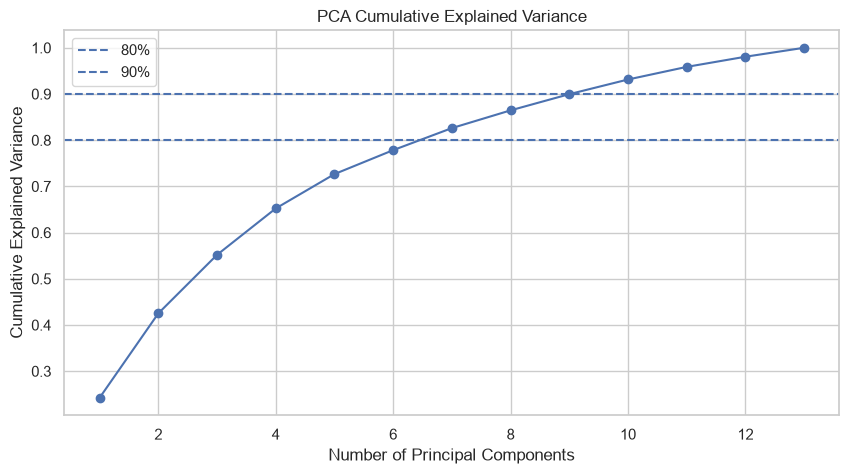

In [8]:
plt.figure(figsize=(10,5))
plt.plot(range(1,len(explained)+1),np.cumsum(explained),marker="o")
plt.axhline(.80,linestyle="--",label="80%")
plt.axhline(.90,linestyle="--",label="90%")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
save_plot("10-explained-variance-plot.png")
plt.show()

## 11. Choosing the Number of Components

A common exploratory approach is to choose enough components to retain a desired proportion of variance.

For example:

```text
PC1 + PC2 + PC3
       ↓
85% variance retained
```

The exact threshold is business/model dependent.

Do **not** automatically assume that 2 components are sufficient just because 2D visualization is convenient.

In [9]:
for threshold in [.70,.80,.90,.95]:
    k=np.argmax(np.cumsum(explained)>=threshold)+1
    print(f"{threshold:.0%} variance → {k} components")

70% variance → 5 components
80% variance → 7 components
90% variance → 10 components
95% variance → 11 components


## 12. 2D PCA Representation

In [10]:
pca_2=PCA(n_components=2)
X_pca_2=pca_2.fit_transform(X_scaled)

pca_df=pd.DataFrame(X_pca_2,columns=["PC1","PC2"])
pca_df["Customer_ID"]=df["Customer_ID"].values

display(pca_df.head())

,PC1,PC2,Customer_ID
0,-0.583838,-1.919082,C00001
1,-1.003035,0.835641,C00002
2,0.892588,-0.613577,C00003
3,-1.595141,-0.438778,C00004
4,0.354360,1.642683,C00005


Saved: output/12-2d-pca-representation.png


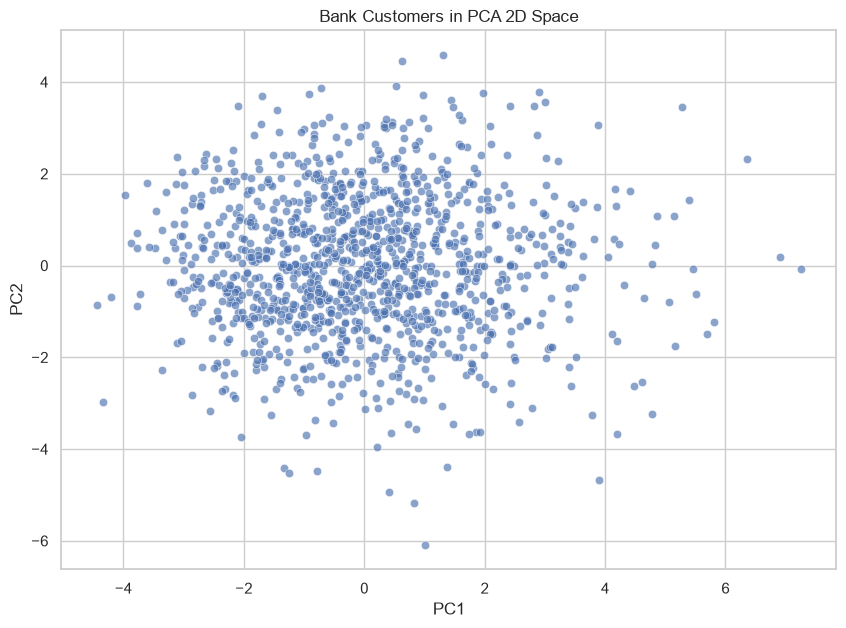

In [11]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df,x="PC1",y="PC2",alpha=.65)
plt.title("Bank Customers in PCA 2D Space")
save_plot("12-2d-pca-representation.png")
plt.show()

## 13. Interpreting PCA Loadings

Loadings indicate how strongly each original feature contributes to a component.

A large positive or negative loading means that the feature contributes strongly to that component.

Sign direction itself is arbitrary; the magnitude is more important for contribution.

In [12]:
loadings=pd.DataFrame(
    pca_2.components_.T,
    index=feature_cols,
    columns=["PC1","PC2"]
)

display(loadings.sort_values("PC1",key=abs,ascending=False))
display(loadings.sort_values("PC2",key=abs,ascending=False))

,PC1,PC2
Avg_Balance,0.370669,-0.175899
Monthly_Transactions,0.352229,0.381046
Product_Count,0.349781,0.101066
Credit_Card_Spend,0.337546,0.145297
Digital_Usage_Score,0.316681,0.409015
Age,0.297071,-0.382179
Investment_Balance,0.282250,0.021427
Credit_Score,0.241062,-0.308924
Monthly_Income,0.240763,-0.156936
Loan_Balance,0.213175,-0.283259


,PC1,PC2
Digital_Usage_Score,0.316681,0.409015
Age,0.297071,-0.382179
Monthly_Transactions,0.352229,0.381046
Tenure_Years,0.196392,-0.362556
Credit_Score,0.241062,-0.308924
Branch_Visits,-0.100740,-0.283425
Loan_Balance,0.213175,-0.283259
ATM_Transactions,-0.154312,-0.258164
Avg_Balance,0.370669,-0.175899
Monthly_Income,0.240763,-0.156936


Saved: output/13-interpreting-pca-loadings.png


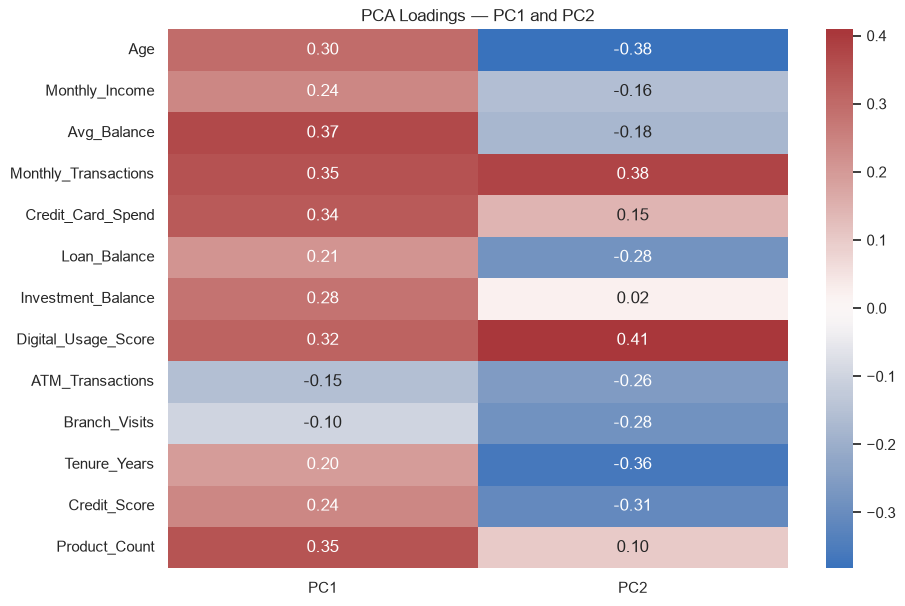

In [13]:
plt.figure(figsize=(10,7))
sns.heatmap(loadings,cmap="vlag",center=0,annot=True,fmt=".2f")
plt.title("PCA Loadings — PC1 and PC2")
save_plot("13-interpreting-pca-loadings.png")
plt.show()

## 14. Business Interpretation Example

If PC1 has strong positive loadings for:

- Avg_Balance
- Investment_Balance
- Monthly_Income
- Product_Count

we might describe PC1 as a **financial relationship / wealth-product dimension**.

If PC2 has strong loadings for:

- Digital_Usage_Score
- ATM_Transactions
- Branch_Visits

we might interpret it as a **channel behavior dimension**.

These labels are analyst interpretations, not automatically generated truths.

## 15. PCA + K-Means Customer Segmentation

K-Means is run on the PCA scores instead of the raw features. Clustering in the reduced space de-noises the data and often produces cleaner, more interpretable segments.


In [14]:
# Use the PCA representation as a visualization/segmentation input
scores=[]
for k in range(2,8):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(X_pca_2)
    scores.append({"K":k,"Silhouette":silhouette_score(X_pca_2,labels)})

cluster_eval=pd.DataFrame(scores)
display(cluster_eval.round(4))

,K,Silhouette
0,2,0.3293
1,3,0.3394
2,4,0.3300
3,5,0.3293
4,6,0.3268
5,7,0.3200


Saved: output/15-pca-k-means-customer-segmentation.png


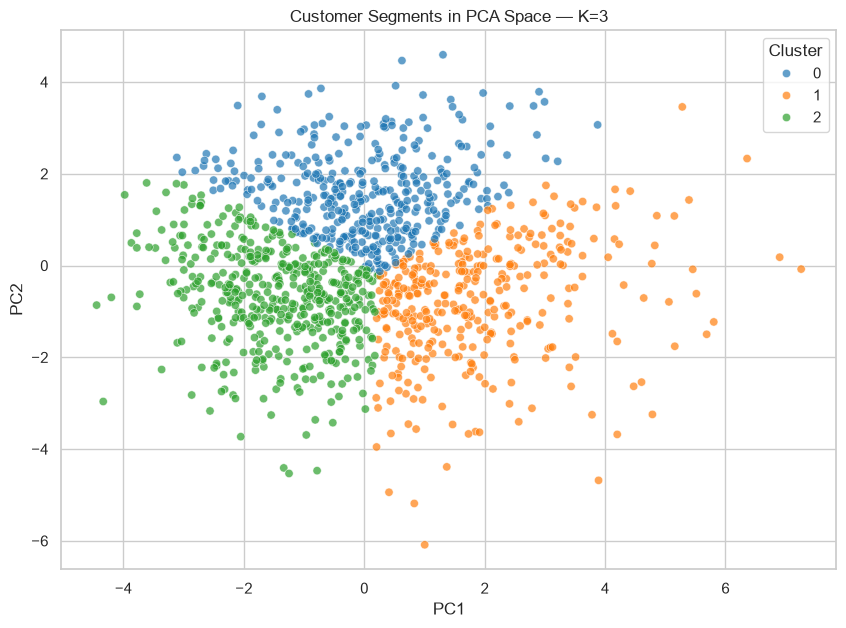

In [15]:
best_k=int(cluster_eval.loc[cluster_eval.Silhouette.idxmax(),"K"])
km=KMeans(n_clusters=best_k,random_state=42,n_init=10)
pca_df["Cluster"]=km.fit_predict(X_pca_2)

plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="tab10",alpha=.7)
plt.title(f"Customer Segments in PCA Space — K={best_k}")
save_plot("15-pca-k-means-customer-segmentation.png")
plt.show()

## 16. Important Modeling Note

There are two different workflows:

### Workflow A — PCA for visualization

```text
Original Features
       ↓
PCA
       ↓
2D Plot
```

### Workflow B — PCA before clustering

```text
Original Features
       ↓
Scaling
       ↓
PCA
       ↓
K-Means
```

The second workflow should validate whether PCA actually improves the clustering objective. PCA is not automatically better than using the original standardized features.

## 17. Compare Clustering With and Without PCA

The same K-Means is fitted on raw scaled features and on PCA scores, and the resulting silhouette scores are compared. This tests whether dimensionality reduction genuinely improves the segmentation or only makes it cheaper to compute.


In [16]:
km_raw=KMeans(n_clusters=best_k,random_state=42,n_init=10)
raw_labels=km_raw.fit_predict(X_scaled)

km_pca=KMeans(n_clusters=best_k,random_state=42,n_init=10)
pca_labels=km_pca.fit_predict(X_pca_2)

comparison=pd.DataFrame({
    "Approach":["Standardized Features","PCA 2 Components"],
    "Silhouette":[silhouette_score(X_scaled,raw_labels),silhouette_score(X_pca_2,pca_labels)]
})

display(comparison.round(4))

,Approach,Silhouette
0,Standardized Features,0.1159
1,PCA 2 Components,0.3394


## 18. t-SNE

t-SNE is a nonlinear dimensionality reduction technique designed primarily for visualization.

It attempts to preserve local neighborhood relationships.

Use it when the question is:

> "Are there local behavioral structures that are difficult to see with PCA?"

Important:
- t-SNE is mainly for visualization.
- Results can depend on hyperparameters.
- Global distances should not be interpreted like ordinary Euclidean distances.
- It is usually not the first choice for production feature compression.

Saved: output/18-t-sne.png


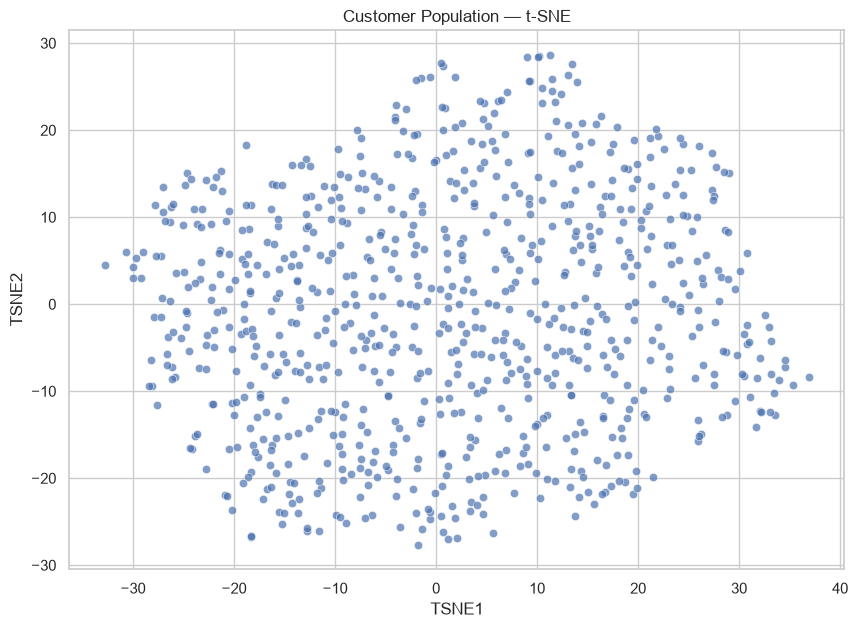

In [17]:
sample_idx=rng.choice(len(X_scaled),size=min(800,len(X_scaled)),replace=False)

tsne=TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne=tsne.fit_transform(X_scaled[sample_idx])

tsne_df=pd.DataFrame(X_tsne,columns=["TSNE1","TSNE2"])
tsne_df["Customer_ID"]=df.iloc[sample_idx]["Customer_ID"].values

plt.figure(figsize=(10,7))
sns.scatterplot(data=tsne_df,x="TSNE1",y="TSNE2",alpha=.7)
plt.title("Customer Population — t-SNE")
save_plot("18-t-sne.png")
plt.show()

## 19. Optional UMAP

UMAP is another nonlinear dimensionality reduction method.

It can often be useful for:
- visualization,
- manifold learning,
- high-dimensional behavioral data.

The library may not be installed in every environment, so this section is optional.

In [18]:
try:
    import umap.umap_ as umap
    reducer=umap.UMAP(n_components=2,random_state=42)
    X_umap=reducer.fit_transform(X_scaled)

    umap_df=pd.DataFrame(X_umap,columns=["UMAP1","UMAP2"])

    plt.figure(figsize=(10,7))
    sns.scatterplot(data=umap_df,x="UMAP1",y="UMAP2",alpha=.7)
    plt.title("Customer Population — UMAP")
    save_plot("19-optional-umap.png")
    plt.show()
except ImportError:
    print("Optional package 'umap-learn' is not installed. Install with: pip install umap-learn")

Optional package 'umap-learn' is not installed. Install with: pip install umap-learn


## 20. PCA vs t-SNE vs UMAP

| Method | Type | Main Use |
|---|---|---|
| PCA | Linear | Compression + interpretation |
| t-SNE | Nonlinear | Local visualization |
| UMAP | Nonlinear | Visualization + manifold learning |

### Practical rule

Use **PCA** when interpretability and reproducibility are important.

Use **t-SNE/UMAP** when exploring nonlinear structure visually.

## 21. Feature Reconstruction

Using `inverse_transform`, the PCA components are mapped back to the original feature space. This links each component to real customer attributes, which is what makes the reduced dimensions business-interpretable.


In [19]:
pca_95=PCA(n_components=.95)
X_95=pca_95.fit_transform(X_scaled)
X_reconstructed=pca_95.inverse_transform(X_95)

reconstruction_error=np.mean((X_scaled-X_reconstructed)**2,axis=1)

recon_df=pd.DataFrame({
    "Customer_ID":df.Customer_ID,
    "Reconstruction_Error":reconstruction_error
}).sort_values("Reconstruction_Error",ascending=False)

display(recon_df.head(20))

,Customer_ID,Reconstruction_Error
647,C00648,0.333870
514,C00515,0.298737
1177,C01178,0.293773
277,C00278,0.281861
1154,C01155,0.256945
844,C00845,0.254987
1073,C01074,0.253604
1050,C01051,0.237590
729,C00730,0.235099
1178,C01179,0.229480


## 22. Reconstruction Error

A useful extension is to inspect observations that PCA reconstructs poorly.

High reconstruction error can indicate:
- unusual customer behavior,
- rare combinations of features,
- potential data quality problems.

This can be used as an exploratory anomaly signal, but it is **not automatically fraud**.

Saved: output/22-reconstruction-error.png


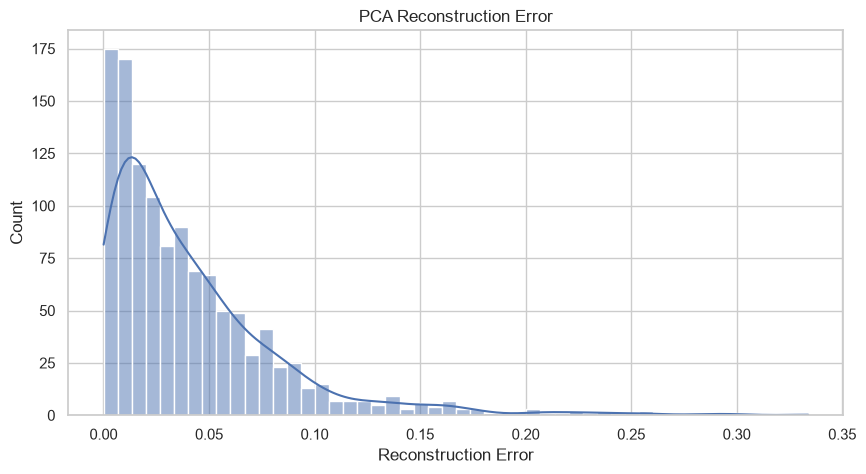

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(reconstruction_error,bins=50,kde=True)
plt.title("PCA Reconstruction Error")
plt.xlabel("Reconstruction Error")
save_plot("22-reconstruction-error.png")
plt.show()

## 23. PCA as Feature Compression

Suppose the original dataset contains 13 numerical features.

We can replace them with:

```text
PC1
PC2
PC3
PC4
PC5
```

This can reduce the number of model inputs.

Potential benefits:
- fewer dimensions,
- less multicollinearity,
- potentially faster models.

Potential cost:
- original feature meaning becomes less direct.

In [21]:
pca_5=PCA(n_components=5)
X_pca_5=pca_5.fit_transform(X_scaled)

print("Original features:",X_scaled.shape[1])
print("Reduced features:",X_pca_5.shape[1])
print("Variance retained:",round(pca_5.explained_variance_ratio_.sum()*100,2),"%")

Original features: 13
Reduced features: 5
Variance retained: 72.66 %


## 24. Important Leakage Consideration

For a production supervised ML pipeline:

```text
Train Data
   ↓
Fit Imputer
   ↓
Fit Scaler
   ↓
Fit PCA
   ↓
Transform Train/Test
```

Do **not** fit PCA on the complete dataset before the train/test split.

Otherwise information from the test set can influence the transformation.

In [22]:
# Example production-safe pipeline
from sklearn.pipeline import Pipeline

pca_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler()),
    ("pca",PCA(n_components=.90))
])

X_reduced=pca_pipeline.fit_transform(X)
print("Reduced dimensions:",X_reduced.shape[1])

Reduced dimensions: 10


## 25. Banking Applications

### Customer Segmentation

```text
Customer Features
       ↓
PCA / UMAP
       ↓
Behavioral Map
       ↓
Clustering
```

### Fraud Analytics

```text
Transaction Features
       ↓
PCA / Autoencoder
       ↓
Anomaly Detection
```

### Recommendation

```text
Customer × Product Matrix
       ↓
Latent Representation
       ↓
Similarity
       ↓
Recommendation
```

### Credit Analytics

Dimensionality reduction can help explore correlated financial indicators before modeling.

## 26. Common Mistakes

1. Running PCA without scaling.
2. Including IDs as features.
3. Assuming PC1 is "the most important feature".
4. Interpreting PCA signs as absolute business meaning.
5. Choosing 2 components solely because visualization is easier.
6. Fitting PCA before train/test split.
7. Treating t-SNE distances as global distances.
8. Assuming dimensionality reduction always improves model performance.

# Final Executive Summary

## Business Problem

Bank customer data can contain many correlated variables.

## Solution

Use dimensionality reduction to create a compact representation.

### PCA

```text
13 Customer Features
        ↓
     Standardize
        ↓
       PCA
        ↓
PC1 ─────── PC2
  \        /
   \      /
    Customer Map
```

### Advanced Methods

```text
PCA
 ↓
Linear structure

t-SNE
 ↓
Local nonlinear structure

UMAP
 ↓
Nonlinear manifold structure
```

### Key takeaway

> **Dimensionality reduction does not simply "delete columns". It transforms the original feature space into a smaller representation that can preserve important structure.**

For banking analytics, it is particularly useful as a foundation for **customer segmentation, anomaly exploration, visualization, and high-dimensional feature compression**.

## 27. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [23]:
loadings.to_csv(OUTPUT_DIR / "pca_loadings.csv", index=False)
print("Saved:", OUTPUT_DIR / "pca_loadings.csv")
cluster_eval.to_csv(OUTPUT_DIR / "pca_kmeans_cluster_evaluation.csv", index=False)
print("Saved:", OUTPUT_DIR / "pca_kmeans_cluster_evaluation.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/pca_loadings.csv
Saved: output/pca_kmeans_cluster_evaluation.csv
  output/10-explained-variance-plot.png
  output/12-2d-pca-representation.png
  output/13-interpreting-pca-loadings.png
  output/15-pca-k-means-customer-segmentation.png
  output/18-t-sne.png
  output/22-reconstruction-error.png
  output/pca_kmeans_cluster_evaluation.csv
  output/pca_loadings.csv
